In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
# read in all the words
DATA_PATH = ROOT / "data" / "names.txt"
words = open(DATA_PATH, 'r').read().splitlines()
words[:8]


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set("".join(words))))

stoi = {char:i+1 for i,char in enumerate(chars)}
stoi['.'] = 0
itos = {v:k for k,v in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
print(itos)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
len(words)


32033

In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
    X,Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(ch, context, ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y 

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size,n_embd),generator=g)
W1 = torch.randn((n_embd*block_size,n_hidden),generator=g)
b1 = torch.randn(n_hidden,generator=g)
W2 = torch.randn((n_hidden,vocab_size),generator=g)
b2 = torch.randn(vocab_size,generator=g)

parameters = [C,W1,b1,W2,b2]

print(sum(p.nelement() for p in parameters)) # we have 11897 parameters

for p in parameters:
    print(p.shape)
    p.requires_grad = True


11897
torch.Size([27, 10])
torch.Size([30, 200])
torch.Size([200])
torch.Size([200, 27])
torch.Size([27])


In [16]:
# training

max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    #forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreactivation = embcat@W1 + b1 
    hpreactivation = (hpreactivation - hpreactivation.mean(dim=0, keepdim=True))/hpreactivation.std(dim=0, keepdim=True)
    h = torch.tanh(hpreactivation)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # if i == 1:
    #     break

    #track stats
    if i % 1000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/  20000: 17.2591
   1000/  20000: 3.3133
   2000/  20000: 3.2902
   3000/  20000: 2.6791
   4000/  20000: 2.6578
   5000/  20000: 2.3046
   6000/  20000: 2.4138
   7000/  20000: 2.5915
   8000/  20000: 2.5684
   9000/  20000: 2.1707
  10000/  20000: 2.4218
  11000/  20000: 2.6314
  12000/  20000: 2.5767
  13000/  20000: 2.5823
  14000/  20000: 2.6030
  15000/  20000: 2.2671
  16000/  20000: 2.6600
  17000/  20000: 2.4855
  18000/  20000: 2.6628
  19000/  20000: 2.3625


In [17]:
-torch.tensor(1/27).log()


tensor(3.2958)

In [18]:
logits = torch.tensor([0.0,0.0,0.0,0.0])
probs = F.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss


(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

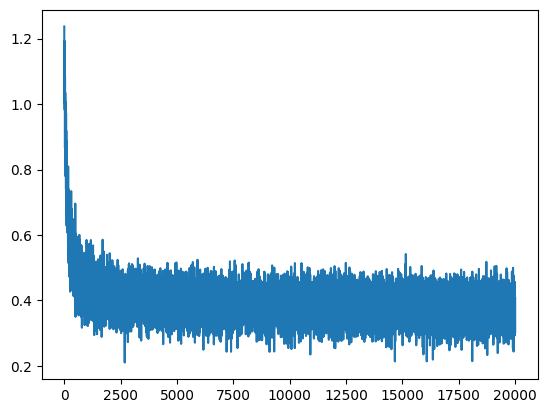

In [19]:
plt.plot(lossi)


(array([166., 250., 199., 170., 151., 193., 218., 171., 197., 181., 179.,
        145., 135., 137.,  93.,  92.,  69.,  97.,  82.,  65.,  58.,  62.,
         53.,  57.,  50.,  52.,  49.,  61.,  58.,  65.,  55.,  65.,  73.,
        100.,  93.,  96.,  89., 115., 156., 133., 164., 171., 154., 171.,
        164., 147., 211., 211., 335., 142.]),
 array([-0.98160601, -0.94228126, -0.90295651, -0.86363176, -0.82430701,
        -0.78498226, -0.74565751, -0.70633276, -0.66700801, -0.62768326,
        -0.58835851, -0.54903376, -0.50970901, -0.47038426, -0.43105951,
        -0.39173476, -0.35241001, -0.31308526, -0.27376051, -0.23443576,
        -0.19511101, -0.15578626, -0.11646151, -0.07713676, -0.03781201,
         0.00151274,  0.04083749,  0.08016224,  0.11948699,  0.15881173,
         0.19813648,  0.23746123,  0.27678598,  0.31611073,  0.35543548,
         0.39476023,  0.43408498,  0.47340973,  0.51273448,  0.55205923,
         0.59138398,  0.63070873,  0.67003348,  0.70935823,  0.74868298,
 

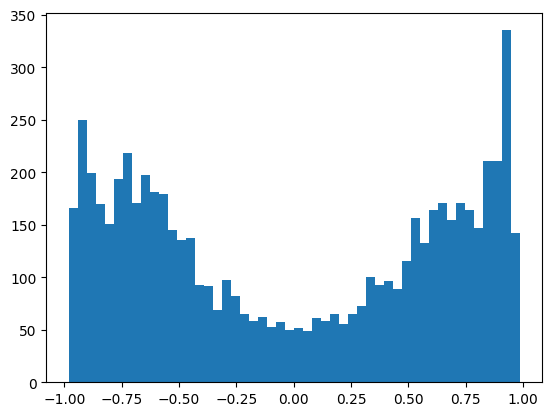

In [20]:
plt.hist(h.view(-1).tolist(),50)


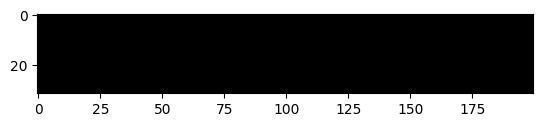

In [21]:
plt.imshow((h.abs() > 0.99).int().tolist(), cmap="gray", interpolation="nearest")


In [22]:
# evaluation

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    hpred = torch.tanh(embcat@W1 + b1)
    logits = hpred @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 7.627070426940918
val 7.605836391448975


In [23]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize ...

    for _step in range(40): # stop at '.' or after 40 chars
        

        #forward pass the neural net
        emb = C[torch.tensor([context])] # 1 example, block size, e embed
        embcat = emb.view(emb.shape[0],-1) # emb.shape[0] should be 1?

        hpreact = embcat@W1 + b1 # pre activation 
        h = torch.tanh(hpreact)
        
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window
        context = context[1:] + [ix]
        out.append(itos[ix])

        # if we get to '.', break
        if ix == 0:
            break
    print (''.join(out))


mrigh.
mhayvmhckagdur.
algsyry.
cjerlonn.
ca.
cwrdkh.
ivindhhmmish.
elco.
cwidhvukuwdhvukuwdhvuhdrvahl.
jwch.
trck.
rwckydhan.
cuddhvukuwddhvukuwdhvukuwdhvukuwdhvukuhh
anga.
jamuychanujld.
jnde.
cwrdka.
jvikh.
phrd.
jwhgundhhmmbxkhvd.


# Part 3 Diagnostic Plots: Activations, Gradients, and BatchNorm

This section mirrors the diagnostic workflow from Karpathy's Makemore Part 3 notebook and lecture. The goal is not just to get a lower loss. The goal is to learn how to look inside a network and tell whether signal is flowing cleanly.

Reference map from the lecture transcript and notebook:

| Diagnostic | What it answers | Main knobs to test |
| --- | --- | --- |
| Initial loss and logits | Is the model overconfident before learning? | output bias, final-layer weight scale |
| Forward activation histograms | Are layer outputs centered and reasonably spread? | hidden gain, activation function, depth, BatchNorm |
| `tanh` saturation mask and saturation % | Is `tanh` stuck near `-1` or `1`? | hidden gain, bias scale, learning rate, BatchNorm |
| Backward gradient histograms | Do gradients have similar scale across layers? | activation function, gain, depth, BatchNorm |
| Parameter grad:data ratio | Is the raw gradient huge or tiny relative to the parameter? | initialization scale, final-layer scale, depth |
| Update:data ratio over time | Is SGD changing weights by a sensible fraction each step? | learning rate, optimizer, BatchNorm, initialization |
| BatchNorm comparison | Does normalization repair activation/gradient scale? | BN placement, BN momentum, hidden gain, output BN |

The knobs below are deliberately exposed. Try `gain=1.0`, `gain=5/3`, `gain=3.0`, `activation="identity"`, `use_bn=True`, and different learning rates. The plots should make the failure mode visible before you wait for a long training run.


In [24]:
# Diagnostic model helpers. These are intentionally tiny PyTorch-like modules.
# They retain their latest output so we can plot activations and gradients.

import math

class Linear:
    def __init__(self, fan_in, fan_out, generator, *, gain=1.0, weight_scale=None, bias=True, name="linear"):
        std = gain / math.sqrt(fan_in) if weight_scale is None else weight_scale
        self.W = torch.randn((fan_in, fan_out), generator=generator) * std
        self.b = torch.zeros(fan_out) if bias else None
        self.name = name
        self.out = None

    def __call__(self, x):
        self.out = x @ self.W
        if self.b is not None:
            self.out = self.out + self.b
        return self.out

    def parameters(self):
        params = [(f"{self.name}.W", self.W)]
        if self.b is not None:
            params.append((f"{self.name}.b", self.b))
        return params


class BatchNorm1d:
    def __init__(self, dim, *, momentum=0.01, eps=1e-5, name="bn"):
        self.gamma = torch.ones((1, dim))
        self.beta = torch.zeros((1, dim))
        self.running_mean = torch.zeros((1, dim))
        self.running_var = torch.ones((1, dim))
        self.momentum = momentum
        self.eps = eps
        self.training = True
        self.name = name
        self.out = None

    def __call__(self, x):
        if self.training:
            mean = x.mean(0, keepdim=True)
            var = x.var(0, keepdim=True, unbiased=False)
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var
        else:
            mean = self.running_mean
            var = self.running_var
        self.out = self.gamma * (x - mean) / torch.sqrt(var + self.eps) + self.beta
        return self.out

    def parameters(self):
        return [(f"{self.name}.gamma", self.gamma), (f"{self.name}.beta", self.beta)]


class Tanh:
    def __init__(self, name="tanh"):
        self.name = name
        self.out = None

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


class Identity:
    def __init__(self, name="identity"):
        self.name = name
        self.out = None

    def __call__(self, x):
        self.out = x
        return self.out

    def parameters(self):
        return []


def make_diagnostic_model(
    *,
    seed=2147483647,
    n_embd=10,
    n_hidden=100,
    n_layers=5,
    gain=5/3,
    activation="tanh",
    use_bn=False,
    output_bn=False,
    bn_momentum=0.01,
    final_weight_scale=0.01,
):
    g = torch.Generator().manual_seed(seed)
    C = torch.randn((vocab_size, n_embd), generator=g)
    layers = []
    fan_in = block_size * n_embd

    for i in range(n_layers):
        # When BN follows a Linear, the Linear bias is redundant: BN subtracts the batch mean,
        # then learns its own shift through beta.
        layers.append(Linear(
            fan_in,
            n_hidden,
            g,
            gain=gain,
            bias=not use_bn,
            name=f"linear{i+1}",
        ))
        if use_bn:
            layers.append(BatchNorm1d(n_hidden, momentum=bn_momentum, name=f"bn{i+1}"))
        if activation == "tanh":
            layers.append(Tanh(name=f"tanh{i+1}"))
        elif activation == "identity":
            layers.append(Identity(name=f"identity{i+1}"))
        else:
            raise ValueError("activation must be 'tanh' or 'identity'")
        fan_in = n_hidden

    layers.append(Linear(
        fan_in,
        vocab_size,
        g,
        weight_scale=final_weight_scale,
        bias=not output_bn,
        name="linear_out",
    ))
    if output_bn:
        layers.append(BatchNorm1d(vocab_size, momentum=bn_momentum, name="bn_out"))

    named_parameters = [("C", C)]
    for layer in layers:
        named_parameters.extend(layer.parameters())
    for _, p in named_parameters:
        p.requires_grad = True

    return {"C": C, "layers": layers, "params": named_parameters, "generator": g}


def forward_model(model, X, *, retain_layer_outputs=False):
    emb = model["C"][X]
    x = emb.view(emb.shape[0], -1)
    for layer in model["layers"]:
        x = layer(x)
        if retain_layer_outputs and getattr(layer, "out", None) is not None:
            layer.out.retain_grad()
    return x


def zero_grad(model):
    for _, p in model["params"]:
        p.grad = None


def one_batch_snapshot(**config):
    model = make_diagnostic_model(**config)
    g = model["generator"]
    ix = torch.randint(0, Xtr.shape[0], (64,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    logits = forward_model(model, Xb, retain_layer_outputs=True)
    loss = F.cross_entropy(logits, Yb)
    zero_grad(model)
    loss.backward()
    return {"model": model, "loss": loss.item(), "Xb": Xb, "Yb": Yb, "config": config}


def monitored_layers(snapshot, kinds=(Tanh,)):
    layers = snapshot["model"]["layers"]
    return [layer for layer in layers if isinstance(layer, kinds)]


def safe_log10(x, eps=1e-20):
    return math.log10(max(float(x), eps))


## 1. Forward Activations And `tanh` Saturation

How to read the activation histograms:

- A healthy `tanh` layer is centered near `0`, uses a reasonable part of `[-1, 1]`, and does not pile most values at the edges.
- `sat %` is the fraction of outputs with `abs(tanh_output) > 0.97`. High saturation means the layer is spending too much time in the flat tails of `tanh`.
- The saturation mask is `[batch, hidden_neuron]`. White cells are saturated activations. A whole white column means that neuron is saturated for every example in the batch.

Why gain matters:

- `gain=1` often makes the signal conservative. In deep stacks, repeated conservative transformations can make activations and gradients shrink.
- `gain=5/3` is a common `tanh` gain. It compensates for `tanh` being contractive while trying not to throw values into the flat tails.
- `gain=3` usually pushes pre-activations too wide. `tanh` squashes them into `-1` and `1`, so gradients through those units get killed.


gain=1.0 initial loss 3.3003
gain=5/3 initial loss 3.2975
gain=3.0 initial loss 3.2890


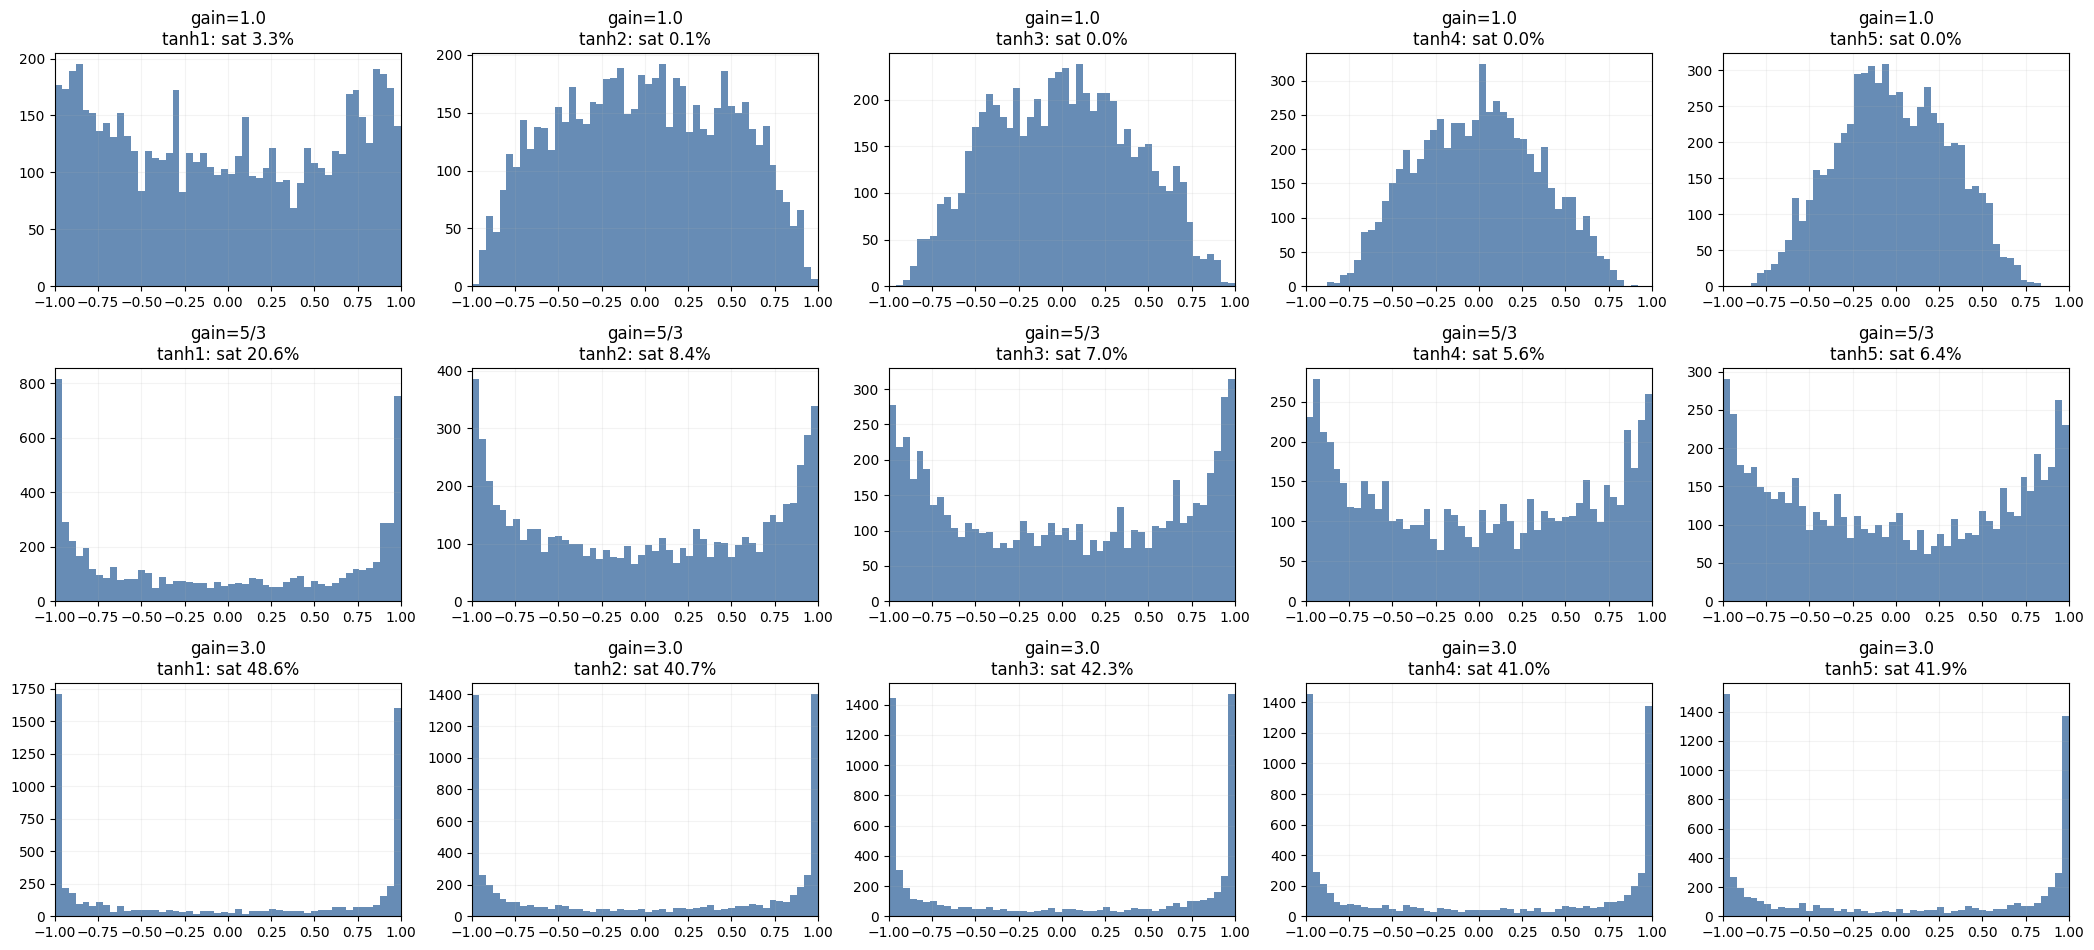

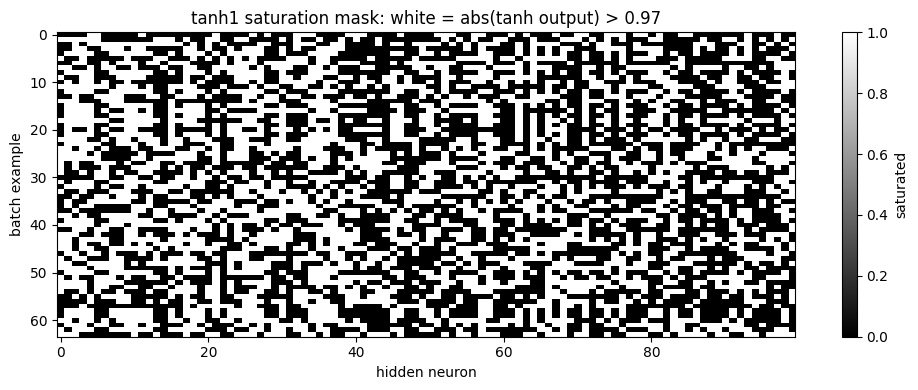

In [25]:
def plot_activation_histograms(snapshots, *, threshold=0.97):
    nrows = len(snapshots)
    max_layers = max(len(monitored_layers(s, (Tanh, Identity))) for s in snapshots.values())
    plt.figure(figsize=(4.2 * max_layers, 3.2 * nrows))

    plot_i = 1
    for row_name, snapshot in snapshots.items():
        layers = monitored_layers(snapshot, (Tanh, Identity))
        for layer in layers:
            ax = plt.subplot(nrows, max_layers, plot_i)
            values = layer.out.detach().view(-1)
            if isinstance(layer, Tanh):
                sat = (values.abs() > threshold).float().mean().item() * 100
                ax.hist(values.tolist(), bins=50, range=(-1, 1), color="#4C78A8", alpha=0.85)
                ax.set_xlim(-1, 1)
                ax.set_title(f"{row_name}\n{layer.name}: sat {sat:.1f}%")
            else:
                ax.hist(values.tolist(), bins=50, color="#F58518", alpha=0.85)
                ax.set_title(f"{row_name}\n{layer.name}: std {values.std().item():.2f}")
            ax.grid(alpha=0.15)
            plot_i += 1
        plot_i += max_layers - len(layers)

    plt.tight_layout()


def plot_saturation_mask(snapshot, *, layer_number=1, threshold=0.97):
    tanh_layers = monitored_layers(snapshot, (Tanh,))
    layer = tanh_layers[layer_number - 1]
    mask = (layer.out.detach().abs() > threshold)
    plt.figure(figsize=(10, 4))
    plt.imshow(mask.int().tolist(), cmap="gray", interpolation="nearest", aspect="auto")
    plt.title(f"{layer.name} saturation mask: white = abs(tanh output) > {threshold}")
    plt.xlabel("hidden neuron")
    plt.ylabel("batch example")
    plt.colorbar(label="saturated")
    plt.tight_layout()


gain_snaps = {
    "gain=1.0": one_batch_snapshot(gain=1.0, use_bn=False, activation="tanh"),
    "gain=5/3": one_batch_snapshot(gain=5/3, use_bn=False, activation="tanh"),
    "gain=3.0": one_batch_snapshot(gain=3.0, use_bn=False, activation="tanh"),
}

for name, snapshot in gain_snaps.items():
    print(name, "initial loss", f"{snapshot['loss']:.4f}")

plot_activation_histograms(gain_snaps)
plot_saturation_mask(gain_snaps["gain=3.0"], layer_number=1)


What can go wrong here:

- If the histogram is two spikes near `-1` and `1`, `tanh` is saturated. The forward pass still produces numbers, but the backward pass gets multiplied by `1 - tanh(x)^2`, which is almost zero at the edges.
- If every histogram is extremely narrow around `0`, the network is almost linear at initialization. It may train, but the nonlinear capacity is underused.
- If the saturation mask has entire white columns, those hidden units are effectively dead for that batch. They are not getting useful local gradient through `tanh`.


## 2. Backward Gradients Across Layers

For gradient histograms, the healthy pattern is not "all gradients are large." The healthy pattern is comparable scale across layers.

Look for:

- Similar gradient standard deviations from early to late hidden layers.
- No layer with gradients collapsed to almost zero.
- No layer with gradients much wider than all others.

The `identity` version removes `tanh`. That avoids `tanh` saturation, but it also removes the nonlinear computation. A deep stack of Linear + Identity layers is still one big linear map, and its activation/gradient scale is governed almost entirely by repeated matrix multiplication. If the scale is off, values can diffuse, shrink, or grow without a nonlinear check.


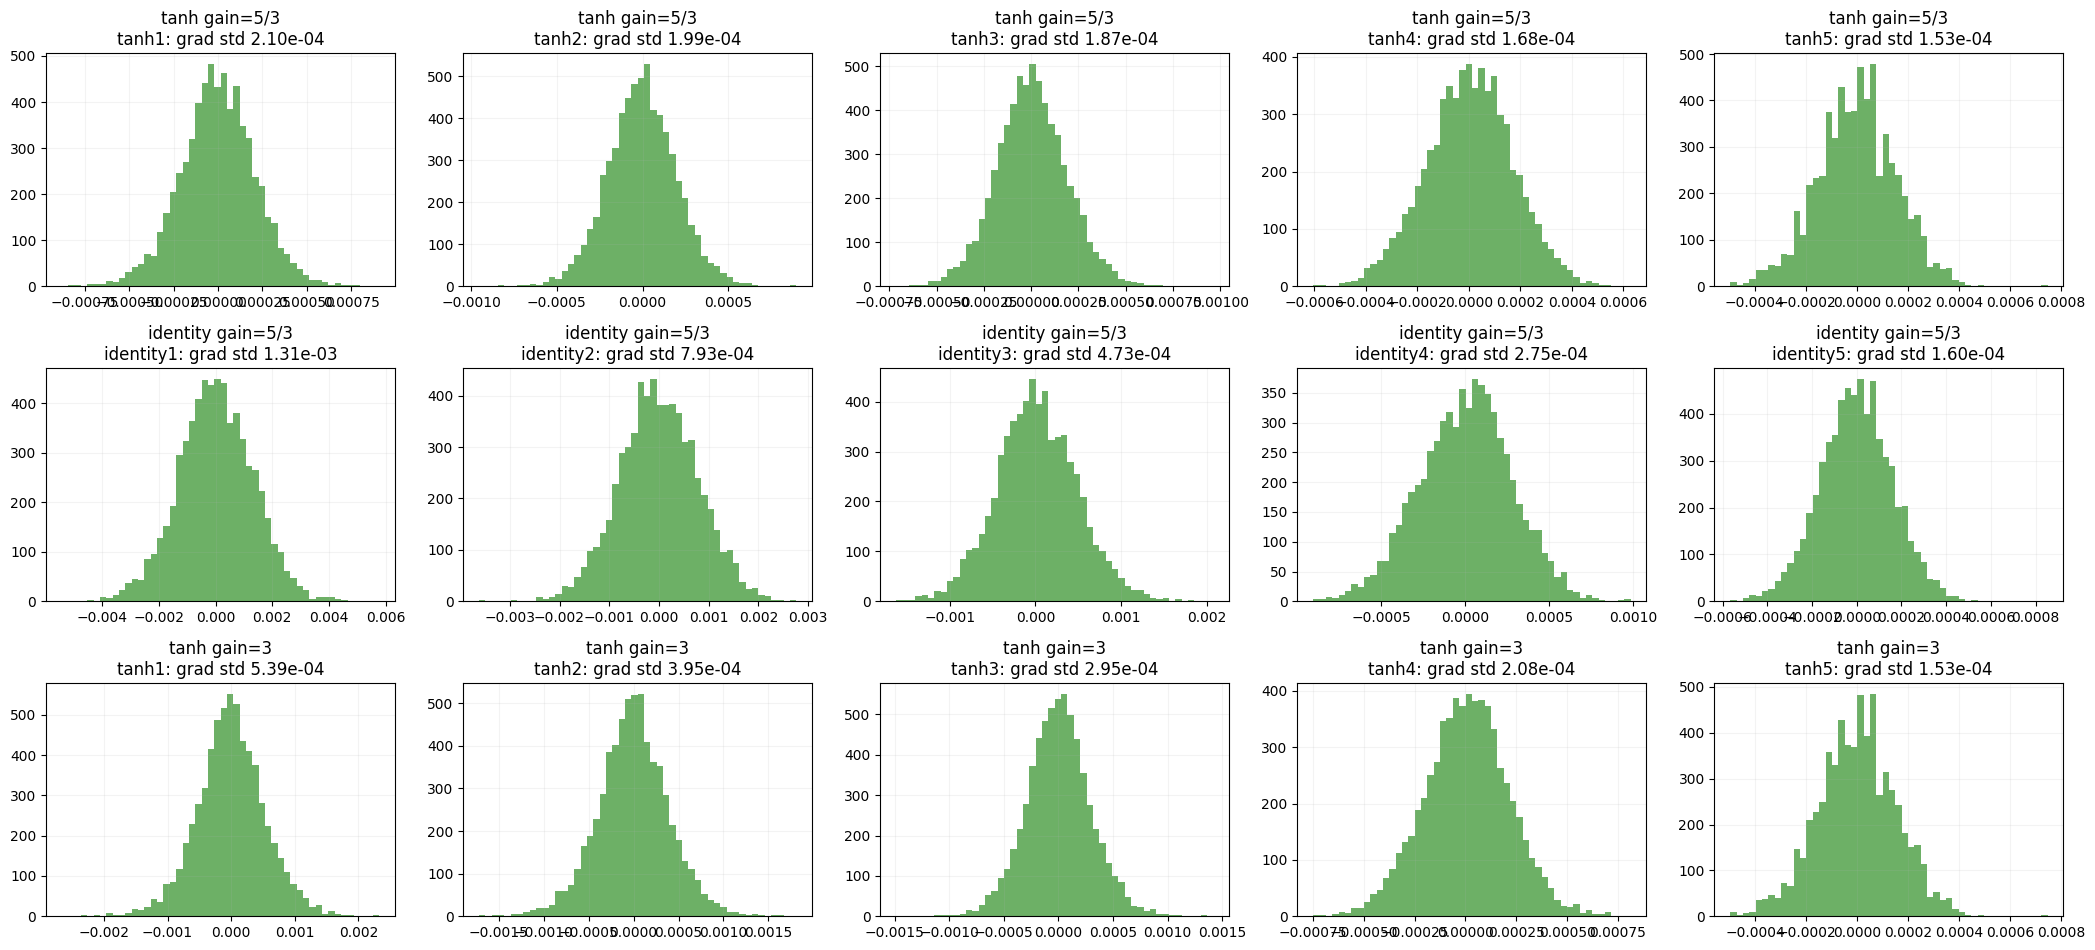

In [26]:
def plot_layer_gradient_histograms(snapshots):
    nrows = len(snapshots)
    max_layers = max(len(monitored_layers(s, (Tanh, Identity))) for s in snapshots.values())
    plt.figure(figsize=(4.2 * max_layers, 3.2 * nrows))

    plot_i = 1
    for row_name, snapshot in snapshots.items():
        layers = monitored_layers(snapshot, (Tanh, Identity))
        for layer in layers:
            ax = plt.subplot(nrows, max_layers, plot_i)
            grad = layer.out.grad.detach().view(-1)
            ax.hist(grad.tolist(), bins=50, color="#54A24B", alpha=0.85)
            ax.set_title(f"{row_name}\n{layer.name}: grad std {grad.std().item():.2e}")
            ax.grid(alpha=0.15)
            plot_i += 1
        plot_i += max_layers - len(layers)

    plt.tight_layout()


grad_snaps = {
    "tanh gain=5/3": one_batch_snapshot(gain=5/3, use_bn=False, activation="tanh"),
    "identity gain=5/3": one_batch_snapshot(gain=5/3, use_bn=False, activation="identity"),
    "tanh gain=3": one_batch_snapshot(gain=3.0, use_bn=False, activation="tanh"),
}
plot_layer_gradient_histograms(grad_snaps)


What can go wrong here:

- Saturated `tanh` layers show weak gradients because their local derivative is tiny.
- A no-nonlinearity network may show gradients that are not killed by `tanh`, but the model has lost depth-wise nonlinear representation power. If the repeated Linear scales are wrong, gradient histograms drift layer by layer.
- If one layer's gradient histogram is much wider than the others, that layer can dominate training. If one is much narrower, that layer learns slowly.


## 3. Parameter Grad:Data Ratio

This plot compares raw gradient scale to parameter scale:

```text
log10(std(parameter_gradient) / std(parameter_data))
```

Why this matters:

- A gradient that is tiny relative to the parameter means SGD has little signal to move that parameter.
- A gradient that is huge relative to the parameter means that parameter is receiving a much stronger training signal than the rest.
- The final layer often looks high because it is directly connected to the loss, and because we intentionally initialize its weights very small (`final_weight_scale=0.01`) to prevent overconfident logits. Small denominator means a larger grad:data ratio.

This does **not** yet include the learning rate. So do not use this plot alone to choose the LR. It tells you where the raw backward signal is uneven.


C              log10 grad:data = -3.01
linear1.W      log10 grad:data = -2.52
linear2.W      log10 grad:data = -2.29
linear3.W      log10 grad:data = -2.35
linear4.W      log10 grad:data = -2.41
linear5.W      log10 grad:data = -2.45
linear_out.W   log10 grad:data =  0.25


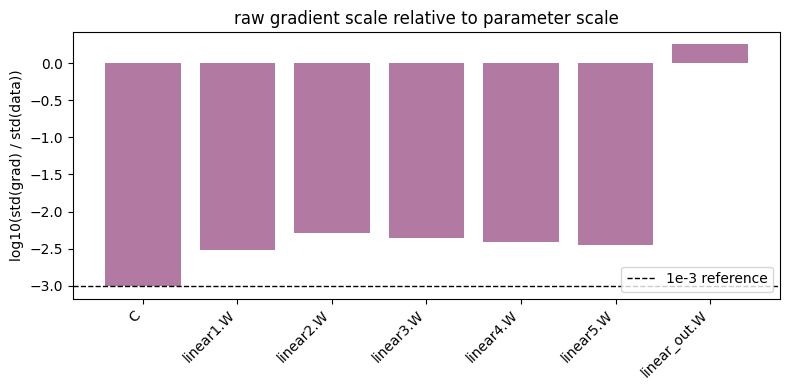

In [27]:
def plot_parameter_grad_data_ratio(snapshot, *, title="parameter grad:data ratio"):
    labels, ratios = [], []
    for name, p in snapshot["model"]["params"]:
        if p.ndim == 2 and p.grad is not None:
            ratio = p.grad.std() / (p.data.std() + 1e-20)
            labels.append(name)
            ratios.append(safe_log10(ratio.item()))

    plt.figure(figsize=(max(8, 0.6 * len(labels)), 4))
    plt.bar(labels, ratios, color="#B279A2")
    plt.axhline(-3, color="black", linestyle="--", linewidth=1, label="1e-3 reference")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("log10(std(grad) / std(data))")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    for label, ratio in zip(labels, ratios):
        print(f"{label:14s} log10 grad:data = {ratio: .2f}")

ratio_snap = one_batch_snapshot(gain=5/3, use_bn=False, activation="tanh", final_weight_scale=0.01)
plot_parameter_grad_data_ratio(ratio_snap, title="raw gradient scale relative to parameter scale")


How to interpret a high last layer:

The last layer can appear to train much faster because the loss talks to it directly. It also has tiny initial weights here, so `std(data)` is small. That makes `grad:data` large. This is why the next plot is more important: it asks how large the actual SGD update is relative to the parameter.


## 4. Update:Data Ratio Over Training

This is usually the most actionable optimizer diagnostic:

```text
log10(std(update) / std(parameter_data))
= log10(std(-lr * grad) / std(parameter_data))
```

The lecture heuristic is that updates around `1e-3` of the parameter scale are often a reasonable ballpark, so the plot marks `-3`.

How to read it:

- Around `-3`: updates are small but meaningful.
- Much below `-4`: learning is probably too slow; parameters barely move.
- Around `-2`, `-1`, or higher: updates are large relative to the parameter; expect noisy loss, instability, or divergence.
- A temporary early spike can happen while the model calibrates bad initial logits or activations. A persistent high ratio is the real warning.


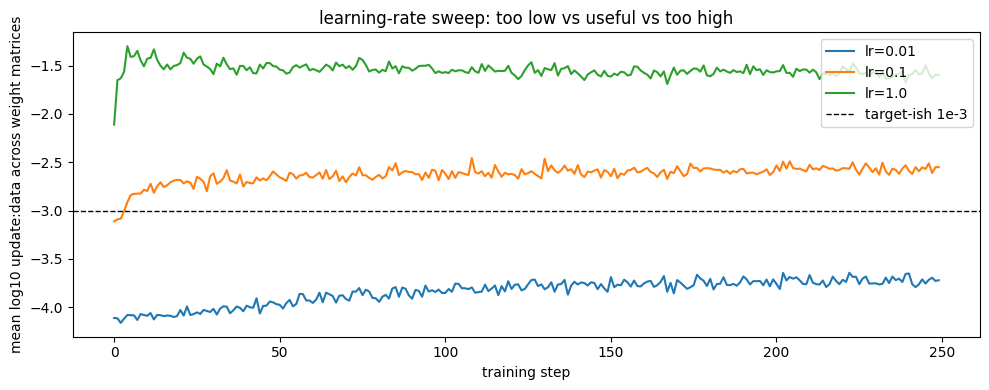

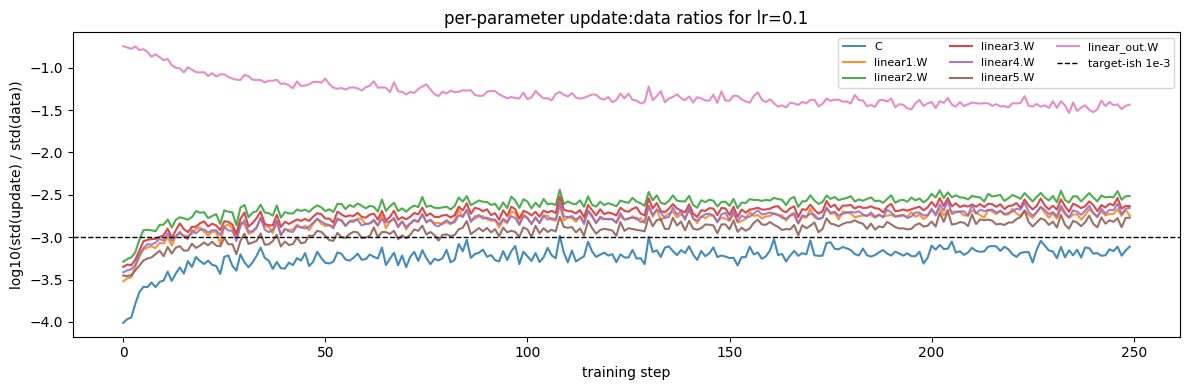

In [28]:
def train_update_ratio_experiment(
    *,
    lr=0.1,
    max_steps=300,
    batch_size=64,
    gain=5/3,
    use_bn=False,
    activation="tanh",
    seed=2147483647,
):
    model = make_diagnostic_model(seed=seed, gain=gain, use_bn=use_bn, activation=activation)
    g = model["generator"]
    weight_names = [name for name, p in model["params"] if p.ndim == 2]
    ud = []
    lossi = []

    for i in range(max_steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix]
        logits = forward_model(model, Xb)
        loss = F.cross_entropy(logits, Yb)
        zero_grad(model)
        loss.backward()

        with torch.no_grad():
            step_ratios = []
            for _, p in model["params"]:
                if p.ndim == 2:
                    update_std = (lr * p.grad).std()
                    data_std = p.data.std()
                    step_ratios.append(safe_log10((update_std / (data_std + 1e-20)).item()))
            ud.append(step_ratios)
            lossi.append(loss.log10().item())
            for _, p in model["params"]:
                p += -lr * p.grad

    return {"model": model, "ud": ud, "lossi": lossi, "weight_names": weight_names, "lr": lr, "use_bn": use_bn, "gain": gain}


def plot_update_ratio_history(run, *, title=None):
    plt.figure(figsize=(12, 4))
    for j, name in enumerate(run["weight_names"]):
        plt.plot([row[j] for row in run["ud"]], label=name, alpha=0.85)
    plt.axhline(-3, color="black", linestyle="--", linewidth=1, label="target-ish 1e-3")
    plt.xlabel("training step")
    plt.ylabel("log10(std(update) / std(data))")
    plt.title(title or f"update:data ratios, lr={run['lr']}")
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()


def plot_learning_rate_update_summary(runs):
    plt.figure(figsize=(10, 4))
    for label, run in runs.items():
        means = [sum(row) / len(row) for row in run["ud"]]
        plt.plot(means, label=label)
    plt.axhline(-3, color="black", linestyle="--", linewidth=1, label="target-ish 1e-3")
    plt.xlabel("training step")
    plt.ylabel("mean log10 update:data across weight matrices")
    plt.title("learning-rate sweep: too low vs useful vs too high")
    plt.legend()
    plt.tight_layout()

lr_runs = {
    "lr=0.01": train_update_ratio_experiment(lr=0.01, max_steps=250, gain=5/3, use_bn=False),
    "lr=0.1": train_update_ratio_experiment(lr=0.1, max_steps=250, gain=5/3, use_bn=False),
    "lr=1.0": train_update_ratio_experiment(lr=1.0, max_steps=250, gain=5/3, use_bn=False),
}

plot_learning_rate_update_summary(lr_runs)
plot_update_ratio_history(lr_runs["lr=0.1"], title="per-parameter update:data ratios for lr=0.1")


Failure modes this plot catches:

- **Learning rate too low:** the curves sit far below `-3`, often near `-5` or lower. Loss may improve, but slowly.
- **Learning rate too high:** the curves rise toward `-2`, `-1`, or above. The model is rewriting weights too aggressively; loss can become noisy or explode.
- **One layer learning much faster:** one line stays well above the others. That layer is getting much larger effective updates and may dominate training.
- **Final layer special case:** if the final layer was initialized very small, it may have a high early ratio. That can be acceptable briefly, but it should not remain wildly separated.


## 5. What BatchNorm Changes

BatchNorm is added after a `Linear` layer and before the nonlinearity:

```text
Linear -> BatchNorm -> Tanh
```

That placement matters because BatchNorm normalizes the pre-activation values that are about to enter `tanh`. It tries to keep them centered near `0` with standard deviation near `1`, then gives the network learnable `gamma` and `beta` so it can recover the scale and offset it wants.

In this notebook helper, when `use_bn=True`, hidden Linear biases are disabled because BatchNorm's mean subtraction cancels them and `beta` becomes the useful learned shift.

A well-training BN run should show:

- lower `tanh` saturation, especially when gain is too large;
- more similar gradient scales across hidden layers;
- update:data curves that are less layer-dependent;
- less sensitivity to the exact hidden gain.


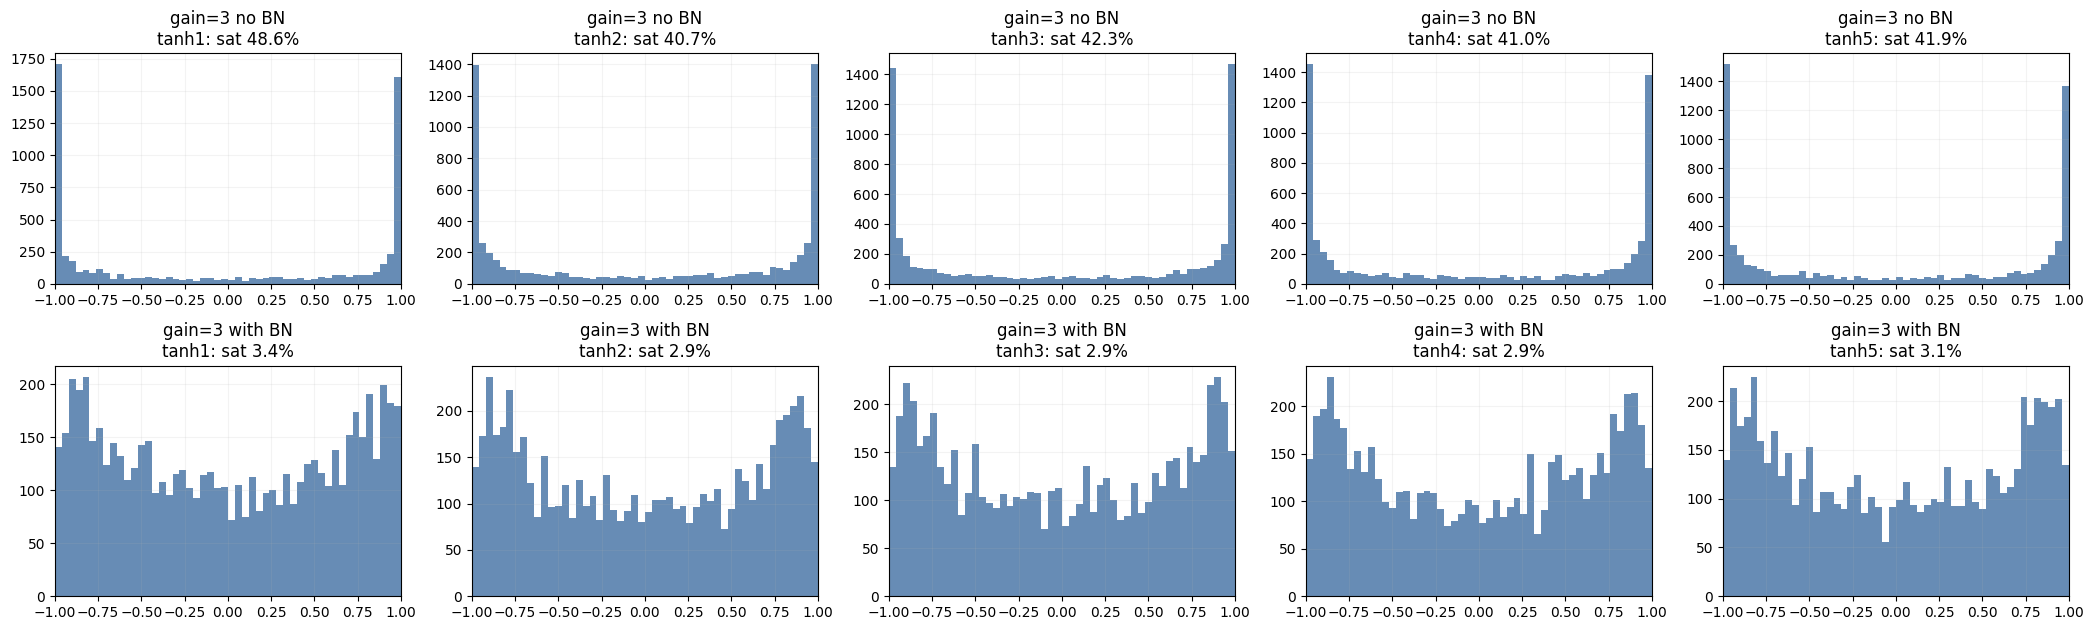

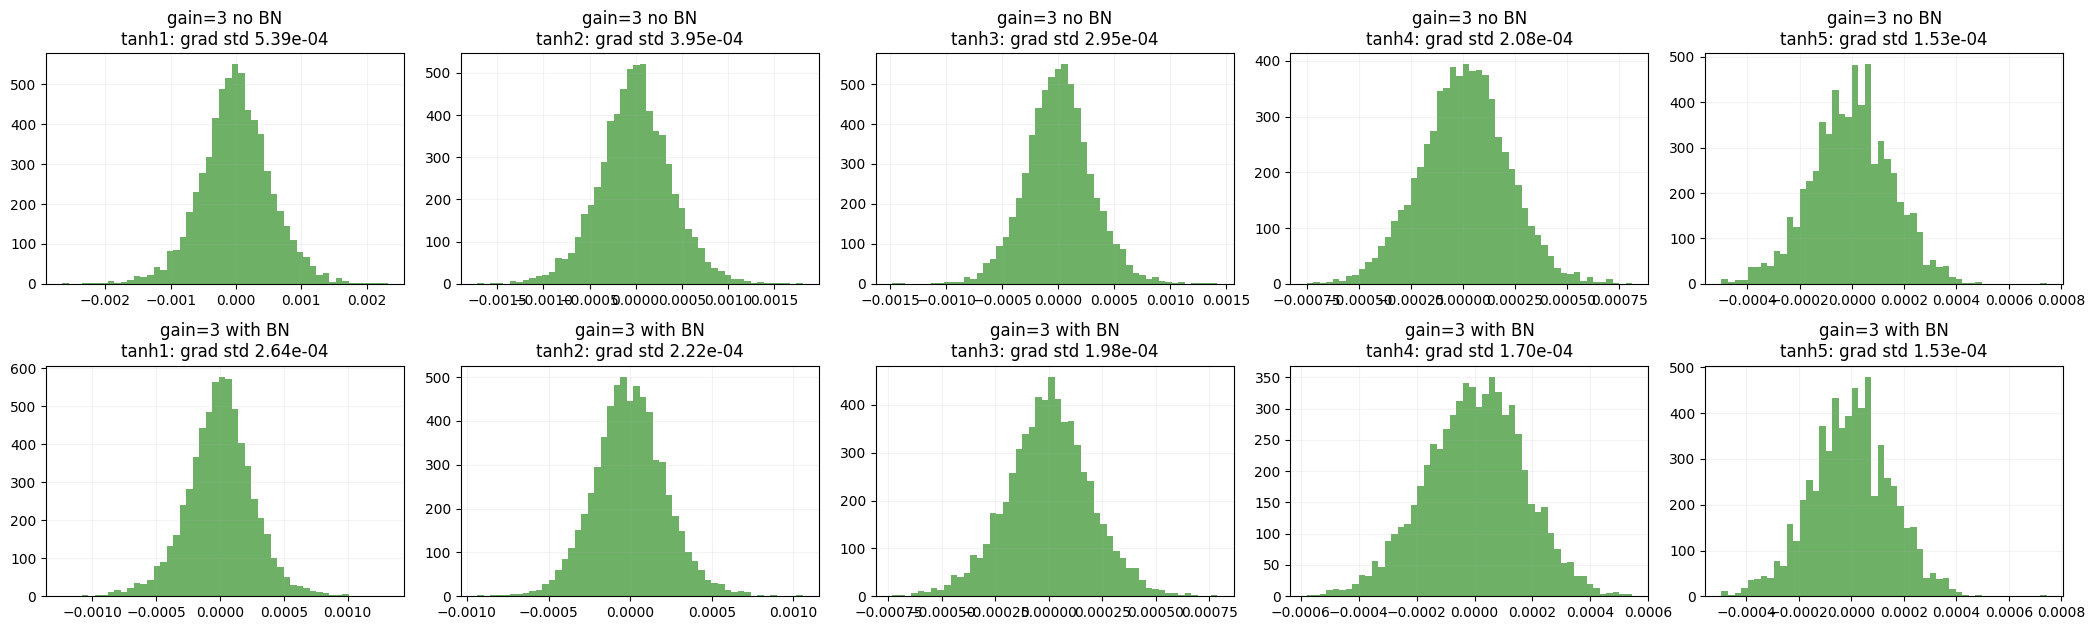

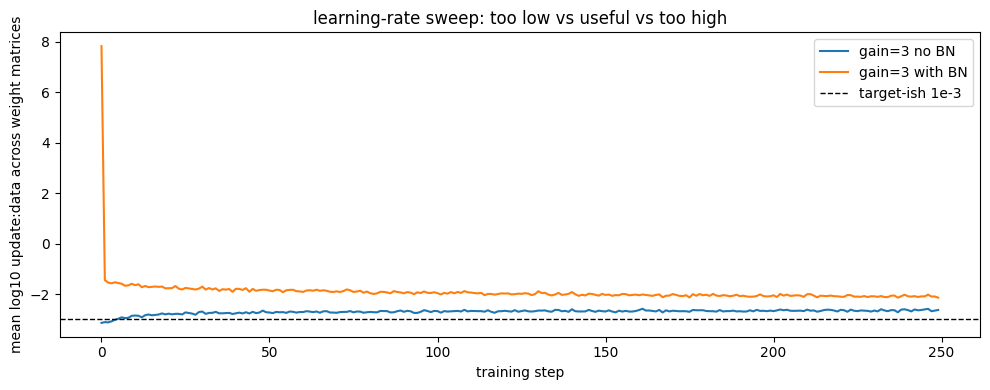

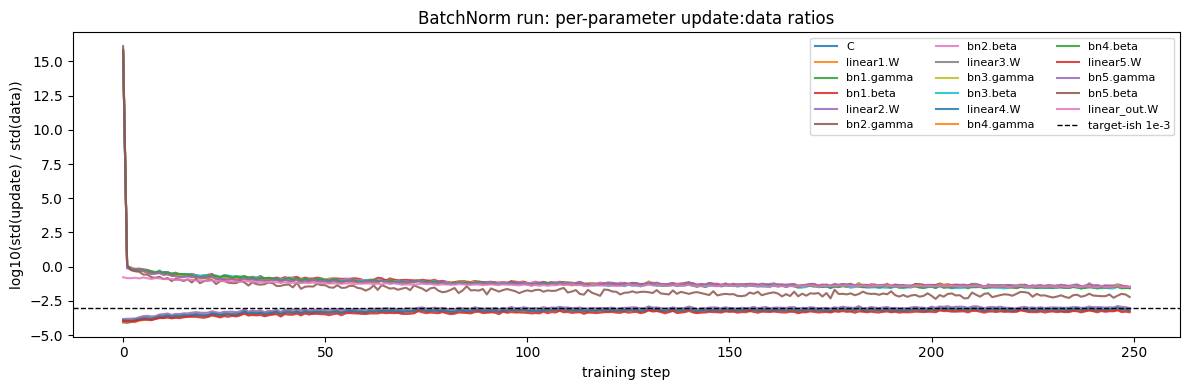

In [29]:
bn_compare_snaps = {
    "gain=3 no BN": one_batch_snapshot(gain=3.0, use_bn=False, activation="tanh"),
    "gain=3 with BN": one_batch_snapshot(gain=3.0, use_bn=True, activation="tanh"),
}

plot_activation_histograms(bn_compare_snaps)
plot_layer_gradient_histograms(bn_compare_snaps)

bn_runs = {
    "gain=3 no BN": train_update_ratio_experiment(lr=0.1, max_steps=250, gain=3.0, use_bn=False),
    "gain=3 with BN": train_update_ratio_experiment(lr=0.1, max_steps=250, gain=3.0, use_bn=True),
}
plot_learning_rate_update_summary(bn_runs)
plot_update_ratio_history(bn_runs["gain=3 with BN"], title="BatchNorm run: per-parameter update:data ratios")


What to focus on when BatchNorm is introduced:

- BN should repair the **input to `tanh`**, so the activation histograms should stop collapsing into two piles at `-1` and `1`.
- BN does not mean every plot becomes perfect. It adds learned `gamma` and `beta`, running statistics, and batch coupling. Those are new moving parts.
- During training, BN uses current batch mean/variance. During inference, it must use running statistics. If sampling looks strange after BN, check whether layers are in inference mode and whether running stats were accumulated long enough.
- BN often makes the model more forgiving to gain mistakes, but it is not a substitute for checking update:data ratios. A bad learning rate can still make BN models train poorly.
